<a href="https://colab.research.google.com/github/MurthyMamidipalli/Resume/blob/main/FitBit_Fitness_Tracker_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
from google.colab import files
uploaded = files.upload()


Saving dailyActivity_merged.csv to dailyActivity_merged.csv


# Importing Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')


In [ ]:
data = pd.read_csv("dailyActivity_merged.csv")

# Explore Data and Data Cleaning


In [ ]:
data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [ ]:
data.shape

(940, 15)

In [ ]:
data.Id.nunique()

33

In [ ]:
cols =['Id','ActivityDate','TotalSteps','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes','Calories']

df = data[cols]

In [ ]:
df

,Id,ActivityDate,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,25,13,328,728,1985
1,1503960366,4/13/2016,10735,21,19,217,776,1797
2,1503960366,4/14/2016,10460,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,29,34,209,726,1745
4,1503960366,4/16/2016,12669,36,10,221,773,1863
...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847
936,8877689391,5/9/2016,20226,73,19,217,1131,3710
937,8877689391,5/10/2016,10733,18,11,224,1187,2832
938,8877689391,5/11/2016,21420,88,12,213,1127,3832


In [ ]:
df.rename(columns={'ActivityDate':'Data'},inplace=True)

In [ ]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,25,13,328,728,1985
1,1503960366,4/13/2016,10735,21,19,217,776,1797
2,1503960366,4/14/2016,10460,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,29,34,209,726,1745
4,1503960366,4/16/2016,12669,36,10,221,773,1863
...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847
936,8877689391,5/9/2016,20226,73,19,217,1131,3710
937,8877689391,5/10/2016,10733,18,11,224,1187,2832
938,8877689391,5/11/2016,21420,88,12,213,1127,3832


In [ ]:
df['TotalMinutes']=df.VeryActiveMinutes + df.FairlyActiveMinutes + df.LightlyActiveMinutes + df.SedentaryMinutes

In [ ]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes
0,1503960366,4/12/2016,13162,25,13,328,728,1985,1094
1,1503960366,4/13/2016,10735,21,19,217,776,1797,1033
2,1503960366,4/14/2016,10460,30,11,181,1218,1776,1440
3,1503960366,4/15/2016,9762,29,34,209,726,1745,998
4,1503960366,4/16/2016,12669,36,10,221,773,1863,1040
...,...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847,1440
936,8877689391,5/9/2016,20226,73,19,217,1131,3710,1440
937,8877689391,5/10/2016,10733,18,11,224,1187,2832,1440
938,8877689391,5/11/2016,21420,88,12,213,1127,3832,1440


In [ ]:
df['TotalHours']=round(df.TotalMinutes / 60)

In [ ]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
0,1503960366,2016-04-12,13162,25,13,328,728,1985,1094,18.0
1,1503960366,2016-04-13,10735,21,19,217,776,1797,1033,17.0
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,1440,24.0
3,1503960366,2016-04-15,9762,29,34,209,726,1745,998,17.0
4,1503960366,2016-04-16,12669,36,10,221,773,1863,1040,17.0
...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,17,4,245,1174,2847,1440,24.0
936,8877689391,2016-05-09,20226,73,19,217,1131,3710,1440,24.0
937,8877689391,2016-05-10,10733,18,11,224,1187,2832,1440,24.0
938,8877689391,2016-05-11,21420,88,12,213,1127,3832,1440,24.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    940 non-null    int64         
 1   Data                  940 non-null    datetime64[ns]
 2   TotalSteps            940 non-null    int64         
 3   VeryActiveMinutes     940 non-null    int64         
 4   FairlyActiveMinutes   940 non-null    int64         
 5   LightlyActiveMinutes  940 non-null    int64         
 6   SedentaryMinutes      940 non-null    int64         
 7   Calories              940 non-null    int64         
 8   TotalMinutes          940 non-null    int64         
 9   TotalHours            940 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(8)
memory usage: 73.6 KB


In [ ]:
df.Data=pd.to_datetime(df.Data)
df.Data.dtypes

dtype('<M8[ns]')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    940 non-null    int64         
 1   Data                  940 non-null    datetime64[ns]
 2   TotalSteps            940 non-null    int64         
 3   VeryActiveMinutes     940 non-null    int64         
 4   FairlyActiveMinutes   940 non-null    int64         
 5   LightlyActiveMinutes  940 non-null    int64         
 6   SedentaryMinutes      940 non-null    int64         
 7   Calories              940 non-null    int64         
 8   TotalMinutes          940 non-null    int64         
 9   TotalHours            940 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(8)
memory usage: 73.6 KB


In [ ]:
df['DayOfWeek'] = df.Data.dt.day_name()

In [ ]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours,DayOfWeek
0,1503960366,2016-04-12,13162,25,13,328,728,1985,1094,18.0,Tuesday
1,1503960366,2016-04-13,10735,21,19,217,776,1797,1033,17.0,Wednesday
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,1440,24.0,Thursday
3,1503960366,2016-04-15,9762,29,34,209,726,1745,998,17.0,Friday
4,1503960366,2016-04-16,12669,36,10,221,773,1863,1040,17.0,Saturday
...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,17,4,245,1174,2847,1440,24.0,Sunday
936,8877689391,2016-05-09,20226,73,19,217,1131,3710,1440,24.0,Monday
937,8877689391,2016-05-10,10733,18,11,224,1187,2832,1440,24.0,Tuesday
938,8877689391,2016-05-11,21420,88,12,213,1127,3832,1440,24.0,Wednesday


In [ ]:
df.isna().sum()

,0
Id,0
Data,0
TotalSteps,0
VeryActiveMinutes,0
FairlyActiveMinutes,0
LightlyActiveMinutes,0
SedentaryMinutes,0
Calories,0
TotalMinutes,0
TotalHours,0


In [ ]:
df.duplicated().sum()

# analyst data

In [ ]:
df.describe()

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,21.164894,13.564894,192.812766,991.210638,2303.609574,1218.753191,20.313830
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,0.000000,0.000000,127.000000,729.750000,1828.500000,989.750000,16.000000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,4.000000,6.000000,199.000000,1057.500000,2134.000000,1440.000000,24.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,1440.000000,24.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,210.000000,143.000000,518.000000,1440.000000,4900.000000,1440.000000,24.000000
std,2.424805e+09,NaN,5087.150742,32.844803,19.987404,109.174700,301.267437,718.166862,265.931767,4.437283


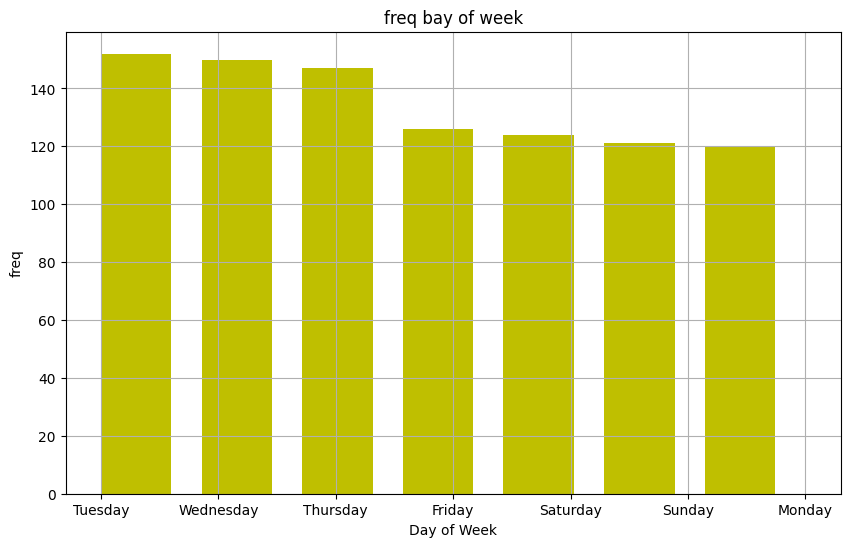

In [ ]:
plt.figure(figsize=((10,6)))
plt.hist(df.DayOfWeek,color='y',bins=7,width =.6,align='mid')

plt.xlabel('Day of Week')
plt.ylabel('freq')
plt.title('freq bay of week')

plt.grid()
plt.show()

In [ ]:
mask = df.drop(['DayOfWeek','Data'],axis=1)

In [ ]:
mask.corr()

,Id,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
Id,1.000000,0.185721,0.303608,0.051158,-0.098754,-0.043319,0.396671,-0.048274,-0.048140
TotalSteps,0.185721,1.000000,0.667079,0.498693,0.569600,-0.327484,0.591568,-0.017285,-0.018152
VeryActiveMinutes,0.303608,0.667079,1.000000,0.312420,0.051926,-0.164671,0.615838,-0.018244,-0.021064
FairlyActiveMinutes,0.051158,0.498693,0.312420,1.000000,0.148820,-0.237446,0.297623,-0.094155,-0.094941
LightlyActiveMinutes,-0.098754,0.569600,0.051926,0.148820,1.000000,-0.437104,0.286718,-0.067049,-0.066640
SedentaryMinutes,-0.043319,-0.327484,-0.164671,-0.237446,-0.437104,1.000000,-0.106973,0.915243,0.914539
Calories,0.396671,0.591568,0.615838,0.297623,0.286718,-0.106973,1.000000,0.094951,0.093314
TotalMinutes,-0.048274,-0.017285,-0.018244,-0.094155,-0.067049,0.915243,0.094951,1.000000,0.998963
TotalHours,-0.048140,-0.018152,-0.021064,-0.094941,-0.066640,0.914539,0.093314,0.998963,1.000000


<Axes: >

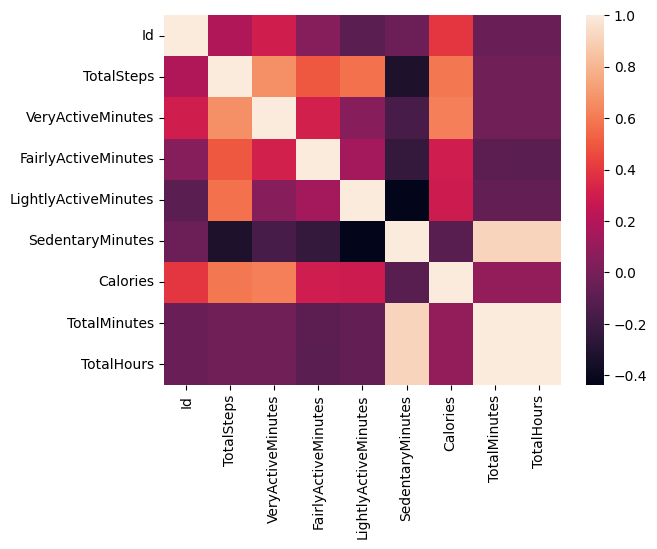

In [ ]:
sns.heatmap(mask.corr())

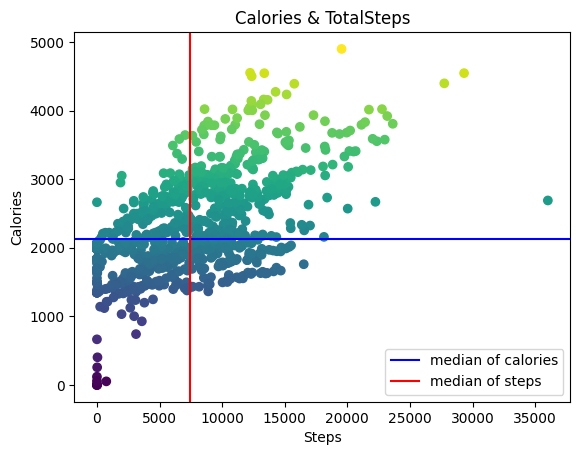

In [ ]:
plt.scatter(mask.TotalSteps,mask.Calories,c=mask.Calories )

median_steps = 7405
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_steps,color = 'r',label = 'median of steps')

plt.xlabel('Steps')
plt.ylabel('Calories')
plt.title('Calories & TotalSteps')

plt.legend()
plt.show()

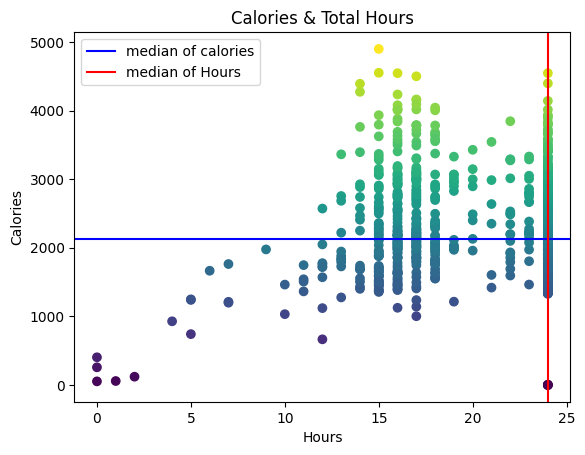

In [ ]:
plt.scatter(mask.TotalHours,mask.Calories,c=mask.Calories )

median_Hours = 24
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_Hours,color = 'r',label = 'median of Hours')

plt.xlabel('Hours')
plt.ylabel('Calories')
plt.title('Calories & Total Hours')

plt.legend()
plt.show()

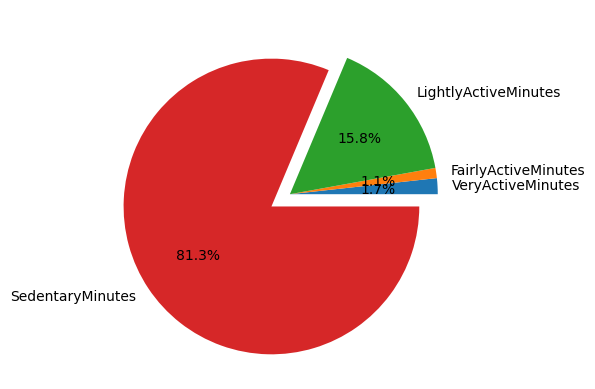

In [ ]:
minutes = [df.VeryActiveMinutes.sum(),df.FairlyActiveMinutes.sum(),
           df.LightlyActiveMinutes.sum(),df.SedentaryMinutes.sum()
          ]
labels = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']

plt.pie(minutes,labels=labels,autopct='%1.1f%%',explode=[0,0,0,0.15])

plt.show()